### Overview

1) Understand the shape of the data (Histograms, box plots, etc.)
2) Data Cleaning
3) Data Exploration
4) Feature Engineering
5) Data Preprocessing for Model
6) Basic Model Building
7) Model Tuning
8) Ensemble Modle Building
9) Results

In [30]:
# Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
# print all files in the titanic directory
for dirname, _, filenames in os.walk("../data"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/test.csv
../data/train.csv
../data/gender_submission.csv


In [31]:
training = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(training.head())
print(test.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [32]:
training['train_test'] = 1
test['train_test'] = 0
test['Survived'] = np.nan
all_data = pd.concat([training,test])

%matplotlib inline
all_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test'],
      dtype='str')

--- DATA INFO ---
<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
 12  train_test   1309 non-null   int64  
dtypes: float64(3), int64(5), str(5)
memory usage: 143.2 KB


--- NUMERICAL SUMMARY ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479,0.680672
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668,0.466394
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


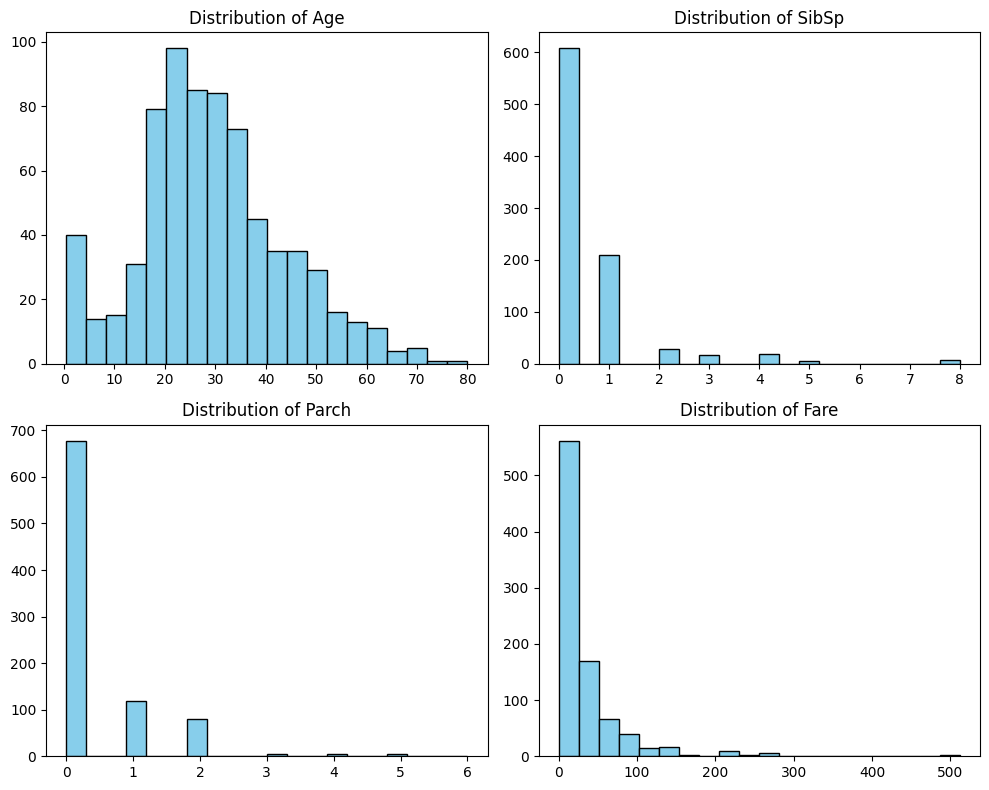

In [33]:
# 1. Check the data types and see where we have missing values (nulls)
print("--- DATA INFO ---")
all_data.info()
print("\n" + "="*50 + "\n")

# 2. Get basic statistics for our numerical columns (mean, min, max, etc.)
print("--- NUMERICAL SUMMARY ---")
display(all_data.describe())
print("\n" + "="*50 + "\n")

# 3. Separate numerical and categorical columns for easier analysis later
df_num = training[['Age','SibSp','Parch','Fare']]
df_cat = training[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

# 4. Plot histograms for all the numerical variables to understand their distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for i, col in enumerate(df_num.columns):
    plt.subplot(2, 2, i + 1)
    plt.hist(df_num[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


In [34]:
# 1. First, make a copy of the original combined dataset
df_clean = all_data.copy()

# 2. Fill missing 'Age' with the median age of everyone on board
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# 3. Fill missing 'Fare' with the median fare
df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# 4. Fill missing 'Embarked' with the most common value ('S')
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# 5. Create our new 'has_cabin' feature (1 if not null, 0 if null)
df_clean['has_cabin'] = df_clean['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# Now we can safely drop the original 'Cabin' column from our clean dataset
df_clean.drop(['Cabin'], axis=1, inplace=True)

# Let's check our new clean dataframe for missing values!
print("--- MISSING VALUES IN df_clean ---")
print(df_clean.isnull().sum())


--- MISSING VALUES IN df_clean ---
PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
train_test       0
has_cabin        0
dtype: int64


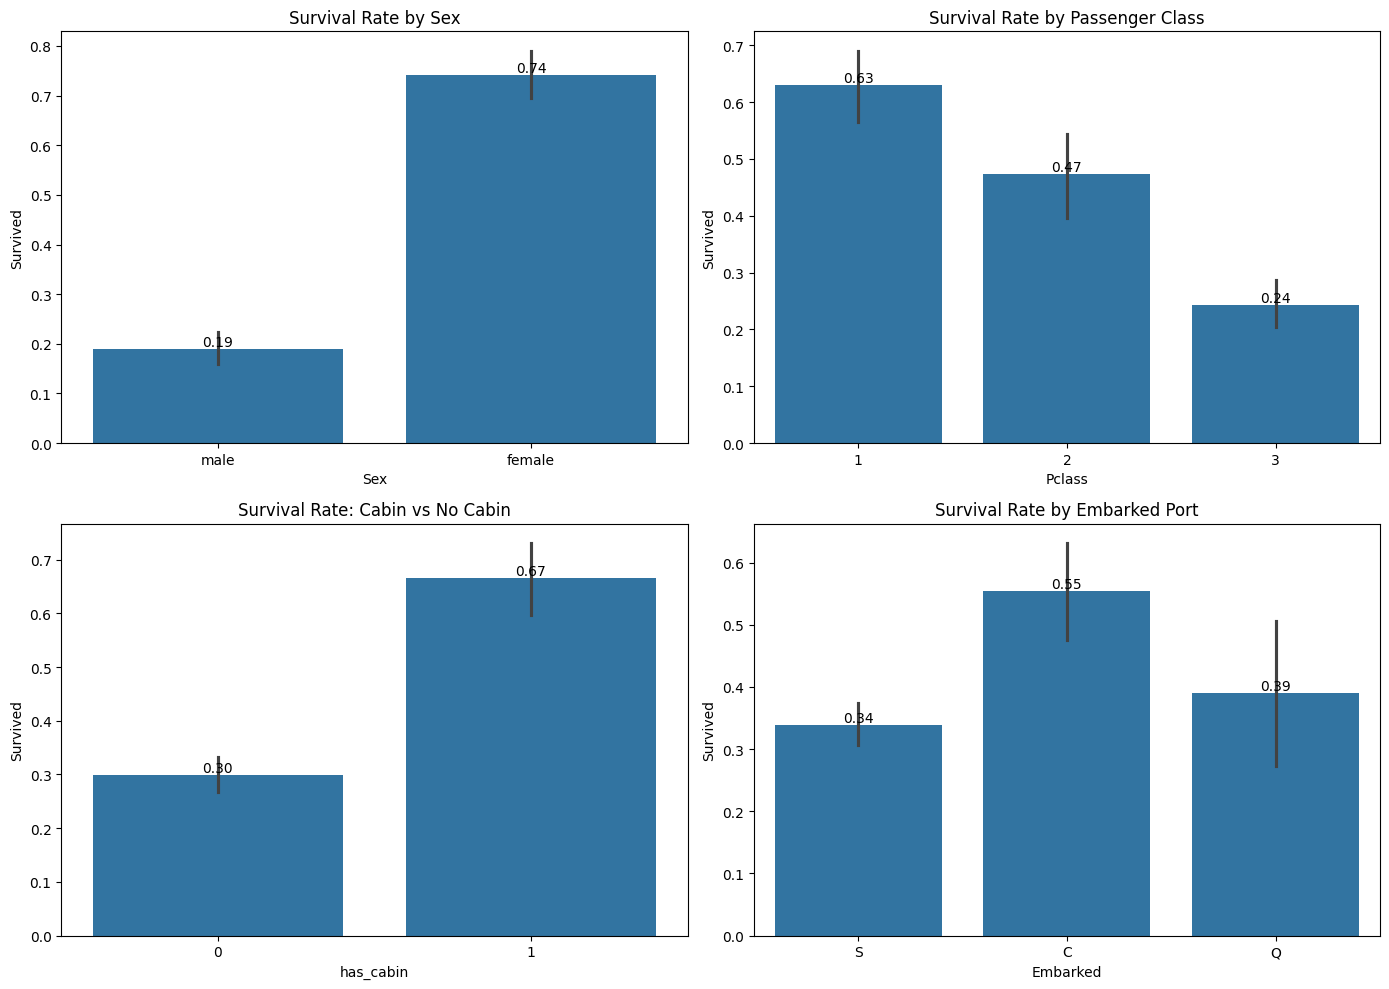

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# We only want to look at the training data where we actually have survival answers
df_train = df_clean[df_clean['train_test'] == 1].copy()

# Set up our grid for plotting (2 rows, 2 columns of plots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df_train, ax=axes[0, 0])
axes[0, 0].set_title('Survival Rate by Sex')
# The line below adds the exact percentage on the bars
for container in axes[0, 0].containers: axes[0, 0].bar_label(container, fmt='%.2f')

# 2. Survival by Passenger Class (Pclass)
sns.barplot(x='Pclass', y='Survived', data=df_train, ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Passenger Class')
for container in axes[0, 1].containers: axes[0, 1].bar_label(container, fmt='%.2f')

# 3. Survival by "has_cabin" (our engineered feature!)
sns.barplot(x='has_cabin', y='Survived', data=df_train, ax=axes[1, 0])
axes[1, 0].set_title('Survival Rate: Cabin vs No Cabin')
for container in axes[1, 0].containers: axes[1, 0].bar_label(container, fmt='%.2f')

# 4. Survival by Port of Embarkation
sns.barplot(x='Embarked', y='Survived', data=df_train, ax=axes[1, 1])
axes[1, 1].set_title('Survival Rate by Embarked Port')
for container in axes[1, 1].containers: axes[1, 1].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()
